**<p>- Họ và tên: Võ Quỳnh Nhi**
**<p>- MSSV: 056306001950**

# Bài tập: Tính và cập nhật trọng số bằng Gradient Descent

Mục tiêu:
- Tính dự đoán từ trọng số.
- Tính sai số và hàm mất mát.
- Tính gradient theo trọng số.
- Cập nhật trọng số theo công thức Gradient Descent.

Ràng buộc: chỉ dùng `numpy` cho phần code và `matplotlib` cho phần vẽ đồ thị.

## Công thức cần nhớ

### Linear Regression

Với mô hình tuyến tính một biến:

$$\hat{y} = wx + b$$

Hàm mất mát trung bình bình phương:

$$L = \frac{1}{n}\sum_{i=1}^{n}(\hat{y}_i - y_i)^2$$

Gradient:

$$\frac{\partial L}{\partial w} = \frac{2}{n}\sum_{i=1}^{n}x_i(\hat{y}_i - y_i)$$

$$\frac{\partial L}{\partial b} = \frac{2}{n}\sum_{i=1}^{n}(\hat{y}_i - y_i)$$

### Logistic Regression

Với mô hình logistic regression một biến, trước hết tính điểm tuyến tính:

$$z = wx + b$$

Đổi `z` thành xác suất bằng hàm sigmoid:

$$\hat{y} = \sigma(z) = \frac{1}{1 + e^{-z}}$$

Trong đó `\hat{y}` là xác suất mẫu thuộc lớp `1`.

Hàm mất mát Binary Cross Entropy cho một mẫu:

$$L = -\left[y\log(\hat{y}) + (1-y)\log(1-\hat{y})\right]$$

Hàm mất mát trung bình cho `n` mẫu:

$$L = -\frac{1}{n}\sum_{i=1}^{n}\left[y_i\log(\hat{y}_i) + (1-y_i)\log(1-\hat{y}_i)\right]$$

Để tránh `log(0)`, chặn xác suất dự đoán trong khoảng rất nhỏ:

$$\hat{y} \leftarrow \mathrm{clip}(\hat{y}, \epsilon, 1 - \epsilon)$$

Ví dụ: `epsilon = 1e-12`.

Với sigmoid kết hợp Binary Cross Entropy, gradient có dạng gọn:

$$\frac{\partial L}{\partial w} = \frac{1}{n}\sum_{i=1}^{n}x_i(\hat{y}_i - y_i)$$

$$\frac{\partial L}{\partial b} = \frac{1}{n}\sum_{i=1}^{n}(\hat{y}_i - y_i)$$

### Cập nhật trọng số bằng Gradient Descent

Dùng cùng công thức cập nhật cho cả hai bài toán:

$$w \leftarrow w - \alpha\frac{\partial L}{\partial w}$$

$$b \leftarrow b - \alpha\frac{\partial L}{\partial b}$$


## Bài 1: Linear Regression với dữ liệu rải quanh một đường thẳng

Bộ dữ liệu bên dưới mô phỏng các điểm `x` nằm rải rác quanh đường thẳng thật gần đúng `y = 2.4x - 1.2`.

Yêu cầu học sinh:
- Tính dự đoán `y_pred`.
- Tính MSE loss.
- Tính gradient theo `w` và `b`.
- Cập nhật `w`, `b` bằng Gradient Descent.
- In loss để quan sát quá trình học.

In [1]:
import numpy as np

# Dữ liệu linear regression
x_linear = np.array([-3.0, -2.4, -1.8, -1.2, -0.6, 0.0, 0.6, 1.2, 1.8, 2.4, 3.0])
y_linear = np.array([-8.7, -6.6, -5.4, -4.0, -2.4, -1.0, 0.0, 1.6, 3.0, 4.7, 6.2])

# Tham số khởi tạo đã cho
w_linear = 0.3
b_linear = 0.0
learning_rate_linear = 0.03
epochs_linear = 120

print("x_linear =", x_linear)
print("y_linear =", y_linear)
print("w_linear ban đầu =", w_linear)
print("b_linear ban đầu =", b_linear)
print("learning_rate_linear =", learning_rate_linear)

x_linear = [-3.  -2.4 -1.8 -1.2 -0.6  0.   0.6  1.2  1.8  2.4  3. ]
y_linear = [-8.7 -6.6 -5.4 -4.  -2.4 -1.   0.   1.6  3.   4.7  6.2]
w_linear ban đầu = 0.3
b_linear ban đầu = 0.0
learning_rate_linear = 0.03


### Bài 1.1: Hoàn thiện hàm cho Linear Regression


In [2]:
# TODO: viết hàm predict_linear(x, w, b)
def predict_linear(x, w, b):
    return w*x + b
# TODO: viết hàm mse_loss(y_true, y_pred)
def mse_loss(y_true, y_pred):
    error = y_pred - y_true
    return np.mean(error ** 2)
# TODO: viết hàm compute_linear_gradients(x, y_true, y_pred)
def compute_linear_gradients (x, y_true, y_pred):
    error = y_pred - y_true
    grad_w = 2 * np.mean(error * x)
    grad_b = 2 * np.mean(error)
    return grad_w, grad_b

### Bài 1.2: Huấn luyện mô hình Linear Regression

Sau khi chạy xong, `w_linear` và `b_linear` nên tiến gần tới đường thẳng phù hợp với dữ liệu.

In [3]:
loss_history_linear = []

for epoch in range(epochs_linear):
    # tính giá trị dự đoán
    y_pred_linear = predict_linear(x_linear, w_linear, b_linear)

    # Tính loss
    loss_linear = mse_loss(y_linear, y_pred_linear)
    loss_history_linear.append(loss_linear)

    # tính gradient
    grad_w_linear, grad_b_linear = compute_linear_gradients(x_linear, y_linear, y_pred_linear)

    # update
    w_linear = w_linear - learning_rate_linear * grad_w_linear
    b_linear = b_linear - learning_rate_linear * grad_b_linear
    
    if epoch % 20 == 0 or epoch == epochs_linear - 1:
        print(f"epoch {epoch:3d} | loss = {loss_linear:8.4f} | w = {w_linear:6.3f} | b = {b_linear:6.3f}")

epoch   0 | loss =  17.2513 | w =  0.754 | b = -0.069
epoch  20 | loss =   0.1517 | w =  2.389 | b = -0.833
epoch  40 | loss =   0.0496 | w =  2.401 | b = -1.055
epoch  60 | loss =   0.0411 | w =  2.402 | b = -1.119
epoch  80 | loss =   0.0404 | w =  2.402 | b = -1.138
epoch 100 | loss =   0.0403 | w =  2.402 | b = -1.143
epoch 119 | loss =   0.0403 | w =  2.402 | b = -1.145


### Bài 1.3: Viết hàm plot kết quả Linear Regression

Viết hàm trực quan hóa để kiểm tra đường thẳng mô hình học được có khớp với dữ liệu hay không.

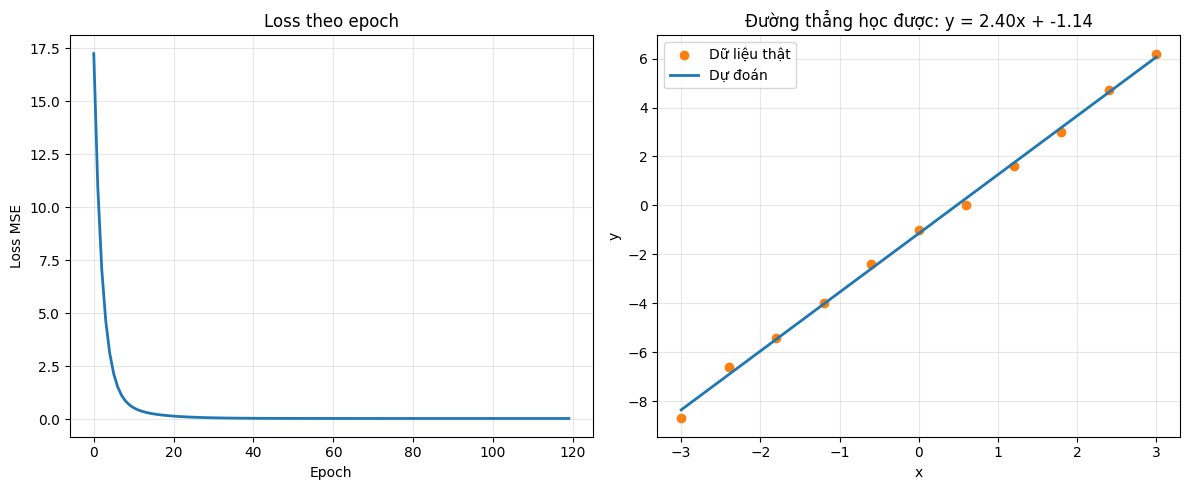

In [4]:
import matplotlib.pyplot as plt

# TODO: viết hàm plot_linear_result(x, y_true, w, b, loss_history)

def plot_linear_result(x_linear, y_linear, w_linear, b_linear, loss_history_linear):
    epochs_axis = np.arange(len(loss_history_linear)) # tạo trục epoch
    y_pred_linear = predict_linear(x_linear, w_linear, b_linear)

    fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

    ax1.plot(epochs_axis, loss_history_linear, color="tab:blue", linewidth=2)
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss MSE")
    ax1.set_title("Loss theo epoch")
    ax1.grid(True, alpha=0.3)
    
    ax2.scatter(x_linear, y_linear, color="tab:orange", label="Dữ liệu thật")
    ax2.plot(x_linear, y_pred_linear, color="tab:blue", linewidth=2, label="Dự đoán")
    ax2.set_xlabel("x")
    ax2.set_ylabel("y")
    ax2.set_title(f"Đường thẳng học được: y = {w_linear:.2f}x + {b_linear:.2f}")
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    plt.tight_layout()
    plt.show() 

plot_linear_result(x_linear, y_linear, w_linear, b_linear, loss_history_linear)

## Bài 2: Logistic Regression

Bộ dữ liệu bên dưới mô phỏng một biến đầu vào `x`. Nhãn `y = 0` thường nằm ở vùng `x` nhỏ hơn, nhãn `y = 1` thường nằm ở vùng `x` lớn hơn.

Yêu cầu học sinh:
- Tính dự đoán `z` từ trọng số.
- Đổi `z` thành xác suất bằng sigmoid.
- Tính Binary Cross Entropy loss.
- Tính gradient theo `w` và `b`.
- Cập nhật `w`, `b` bằng Gradient Descent.

In [5]:
# Dữ liệu logistic regression
x_logistic = np.array([-3.2, -2.7, -2.1, -1.5, -0.9, -0.4, 0.1, 0.5, 0.9, 1.4, 2.0, 2.6, 3.1])
y_logistic = np.array([0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1])

# Tham số khởi tạo
w_logistic = -0.2
b_logistic = 0.1
learning_rate_logistic = 0.15
epochs_logistic = 150

print("x_logistic =", x_logistic)
print("y_logistic =", y_logistic)
print("w_logistic ban đầu =", w_logistic)
print("b_logistic ban đầu =", b_logistic)
print("learning_rate_logistic =", learning_rate_logistic)

x_logistic = [-3.2 -2.7 -2.1 -1.5 -0.9 -0.4  0.1  0.5  0.9  1.4  2.   2.6  3.1]
y_logistic = [0 0 0 0 0 1 0 1 1 1 1 1 1]
w_logistic ban đầu = -0.2
b_logistic ban đầu = 0.1
learning_rate_logistic = 0.15


### Bài 2.1: Hoàn thiện hàm cho Logistic Regression

Dùng `epsilon` nhỏ khi tính log để tránh `log(0)`.

In [6]:
import numpy as np
# TODO: viết hàm sigmoid(z)
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# TODO: viết hàm predict_proba_logistic(x, w, b)
def predict_proba_logistic(x, w, b):
    z = w * x + b
    return sigmoid(z)

# TODO: viết hàm binary_cross_entropy(y_true, y_pred_proba)
def binary_cross_entropy(y_logistic, y_pred_proba):
    epsilon = 1e-12
    y_pred_proba = np.clip(y_pred_proba, epsilon, 1 - epsilon) # để tránh log(0)
    loss = -np.mean(y_logistic * np.log(y_pred_proba) + (1 - y_logistic)*np.log(1 - y_pred_proba))
    return loss

# TODO: viết hàm compute_logistic_gradients(x, y_true, y_pred_proba)
def compute_logistic_gradients(x_logistic, y_logistic, y_pred_proba):
    error = y_pred_proba - y_logistic
    grad_w = np.mean(error * x_logistic)
    grad_b = np.mean(error)
    return grad_w, grad_b

### Bài 2.2: Huấn luyện mô hình Logistic Regression

Sau khi huấn luyện, xác suất dự đoán nên thấp hơn cho phần lớn điểm lớp `0` và cao hơn cho phần lớn điểm lớp `1`.

In [7]:
loss_history_logistic = []

# TODO: chạy vòng lặp Gradient Descent trong epochs_logistic
for epoch in range(epochs_logistic):
    # tính y_pred_proba_logistic bằng predict_proba_logistic
    y_pred_proba_logistic = predict_proba_logistic(x_logistic, w_logistic, b_logistic)
    
    # TODO: tính loss_logistic bằng binary_cross_entropy và lưu vào loss_history_logistic
    loss_logistic = binary_cross_entropy(y_logistic, y_pred_proba_logistic)
    loss_history_logistic.append(loss_logistic)

    # TODO: tính grad_w_logistic, grad_b_logistic bằng compute_logistic_gradients
    grad_w_logistic, grad_b_logistic = compute_logistic_gradients(x_logistic, y_logistic, y_pred_proba_logistic)

    # TODO: cập nhật w_logistic = w_logistic - learning_rate_logistic * grad_w_logistic
    w_logistic -= learning_rate_logistic * grad_w_logistic

    # TODO: cập nhật b_logistic = b_logISTIC - learning_rateLogistic * grad_b_logistic
    b_logistic -= learning_rate_logistic * grad_b_logistic

    # TODO: in epoch, loss_logistic, w_logistic, b_logistic sau mỗi 25 epochs
    if epoch % 25 == 0 or epoch == epochs_logistic - 1:
        print(f"epoch {epoch:3d} | loss = {loss_logistic:8.4f} | w = {w_logistic:6.3f} | b = {b_logistic:6.3f}")
# TODO: tính xác suất cuối cùng cho từng điểm x_logistic
final_proba_logistic = predict_proba_logistic(x_logistic, w_logistic, b_logistic)

# TODO: đổi xác suất thành nhãn dự đoán với ngưỡng 0.5 -> gtri nào >= 0.5 phân vào class 1 và ngược lại
y_pred_label = (final_proba_logistic >= 0.5).astype(int)
# TODO: in xác suất, nhãn dự đoán, và so sánh với y_logistic
print(f"{'Xác suất':>10} | {'Dự đoán':>8} | {'Thực tế':>8}")
for prob, label, y in zip(final_proba_logistic, y_pred_label, y_logistic):
    print(f"{prob:10.4f} | {label:8d} | {y:8d}")

epoch   0 | loss =   0.8660 | w = -0.055 | b =  0.102
epoch  25 | loss =   0.2670 | w =  1.112 | b =  0.161
epoch  50 | loss =   0.2300 | w =  1.467 | b =  0.214
epoch  75 | loss =   0.2167 | w =  1.683 | b =  0.257
epoch 100 | loss =   0.2100 | w =  1.836 | b =  0.291
epoch 125 | loss =   0.2060 | w =  1.953 | b =  0.319
epoch 149 | loss =   0.2036 | w =  2.043 | b =  0.341
  Xác suất |  Dự đoán |  Thực tế
    0.0020 |        0 |        0
    0.0056 |        0 |        0
    0.0189 |        0 |        0
    0.0616 |        0 |        0
    0.1828 |        0 |        0
    0.3832 |        0 |        1
    0.6331 |        1 |        0
    0.7962 |        1 |        1
    0.8984 |        1 |        1
    0.9609 |        1 |        1
    0.9882 |        1 |        1
    0.9965 |        1 |        1
    0.9987 |        1 |        1


### Bài 2.3: Viết hàm plot kết quả Logistic Regression

Viết hàm trực quan hóa để kiểm tra loss giảm và xác suất dự đoán theo từng điểm dữ liệu.

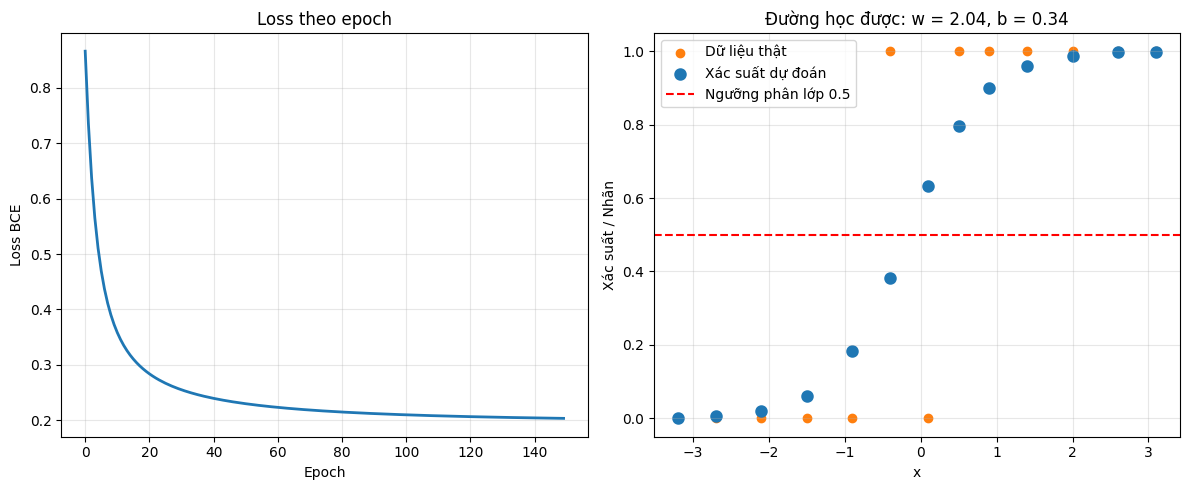

In [8]:
import matplotlib.pyplot as plt

# TODO: viết hàm plot_logistic_result(x, y_true, y_pred_proba, loss_history)
def plot_logistic_result(x_logistic, y_logistic, final_proba_logistic, loss_history_logistic):
    epochs_axis = np.arange(len(loss_history_logistic)) # tạo trục epoch

    fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

    ax1.plot(epochs_axis, loss_history_logistic, color="tab:blue", linewidth=2)
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss BCE")
    ax1.set_title("Loss theo epoch")
    ax1.grid(True, alpha=0.3)

    ax2.scatter(x_logistic, y_logistic, color="tab:orange", label="Dữ liệu thật")
    ax2.scatter(x_logistic, final_proba_logistic, color="tab:blue", label="Xác suất dự đoán", linewidth=3)
    ax2.axhline(y=0.5, color='red', linestyle='--', label='Ngưỡng phân lớp 0.5')
    ax2.set_xlabel("x")
    ax2.set_ylabel("Xác suất / Nhãn")
    ax2.set_title(f"Đường học được: w = {w_logistic:.2f}, b = {b_logistic:.2f}")
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    
    plt.tight_layout()
    plt.show()
plot_logistic_result(x_logistic, y_logistic, final_proba_logistic, loss_history_logistic)